# 07 — Einfache Modelle: Volume-Signal + Per-Horizont-Strategien

**Drei Verbesserungen gegenüber Notebook 06:**

1. **Separate Modelle pro Horizont** — kein geteilter Encoder, der durch unterschiedliche Zeithorizonte verwirrt wird
2. **Volume als Hauptsignal** — Feature Selection zeigt: `ALU_Vol.` dominiert. Hier wird darauf fokussiert.
3. **Sliding-Window Walk-Forward** — Löst das Regime-Break-Problem (COVID 2020, Ukraine 2022):
   statt expandierendem Fenster wird immer nur die letzten ~2 Jahre als Training verwendet.

```
Expanding (06):   [═══════ 2014–2021 ═══════][TEST 2022–2024]
                  ↑ lernt "alte" Regime die 2022 nicht mehr gelten

Sliding (07):     [2020–2022][TEST]
                  [2020.5–2022.5][TEST]
                  [2021–2023][TEST]      ← sieht immer aktuelles Regime
```

In [56]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings("ignore")

_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [_cwd, *_cwd.parents] if (p / "src" / "timeseries_forecast").exists()
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

from timeseries_forecast.data_prep.raw_data import read_raw_metals_data
from timeseries_forecast.data_prep.pipeline import run_data_pipeline
from timeseries_forecast.data_prep.data_merge import merge_all_raw_data
from timeseries_forecast.data_prep.constants import RawMetalsColumn
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations

## Datenladen (identische Pipeline wie Notebook 06)

In [57]:
aluminium_df_cleaned = run_data_pipeline(
    read_raw_metals_data("aluminium"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 4 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2020-09-29', '2020-09-30', '2024-07-30', '2024-07-31'], dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1159 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 15 NaN-Werte insgesamt gefunden:
  Vol.: 15 (0.55%)

0-Werte Check
WARN: 32 0-Werte insgesamt gefunden:
  Vol.: 32 (1.17%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,735 Zeilen
  Zu ergänzende Einträge: 1,159
    RawMetalsColumn.VOLUME: 32 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1159 -> 0 NaN
    Open: 1159 -> 0 NaN
    High: 1159 -> 0 NaN
    Low: 1159 -> 0 NaN
    Vol.: 1206 -> 0 NaN
    Change %: 1159 -> 0 NaN

  Shape vorher:  (2735, 6)
  Shape nachher: (3894, 6)
OK: Interpola

In [58]:
copper_df_cleaned = run_data_pipeline(
    read_raw_metals_data("copper"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 20 NaN-Werte insgesamt gefunden:
  Vol.: 20 (0.73%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1161 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3894, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

In [59]:
gold_df_cleaned = run_data_pipeline(
    read_raw_metals_data("gold"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1135 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 22 NaN-Werte insgesamt gefunden:
  Vol.: 22 (0.80%)

0-Werte Check
WARN: 7 0-Werte insgesamt gefunden:
  Vol.: 7 (0.25%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,760 Zeilen
  Zu ergänzende Einträge: 1,135
    RawMetalsColumn.VOLUME: 7 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1135 -> 0 NaN
    Open: 1135 -> 0 NaN
    High: 1135 -> 0 NaN
    Low: 1135 -> 0 NaN
    Vol.: 1164 -> 0 NaN
    Change %: 1135 -> 0 NaN

  Shape vorher:  (2760, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

In [60]:
lead_df_cleaned = run_data_pipeline(
    read_raw_metals_data("lead"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
    fail_on_row_duplicates=False,
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 6 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2023-03-29', '2023-03-30', '2023-07-27', '2023-07-28',
               '2024-02-26'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 31 NaN-Werte insgesamt gefunden:
  Vol.: 31 (1.12%)

0-Werte Check
WARN: 45 0-Werte insgesamt gefunden:
  Vol.: 45 (1.63%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,757 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 45 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1213 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2757, 

In [61]:
nickel_df_cleaned = run_data_pipeline(
    read_raw_metals_data("nickel"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 21 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2022-05-27', '2022-05-30', '2022-05-31', '2022-06-02',
               '2022-06-03'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1139 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 580 NaN-Werte insgesamt gefunden:
  Vol.: 580 (21.05%)

0-Werte Check
WARN: 40 0-Werte insgesamt gefunden:
  Open: 1 (0.04%)
  High: 1 (0.04%)
  Low: 1 (0.04%)
  Vol.: 37 (1.34%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,755 Zeilen
  Zu ergänzende Einträge: 1,139
    RawMetalsColumn.VOLUME: 37 Nullwerte -> NaN ersetzt
    RawMetalsColumn.OPEN: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.HIGH: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.LOW: 1 Nullwerte -> NaN erse

In [62]:
silver_df_cleaned = run_data_pipeline(
    read_raw_metals_data("silver"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 18 NaN-Werte insgesamt gefunden:
  Vol.: 18 (0.65%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,759 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1159 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2759, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

In [63]:
zinc_df_cleaned = run_data_pipeline(
    read_raw_metals_data("zinc"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 19 NaN-Werte insgesamt gefunden:
  Vol.: 19 (0.69%)

0-Werte Check
WARN: 13 0-Werte insgesamt gefunden:
  Vol.: 13 (0.47%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 13 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1169 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitrei

In [64]:
sp500_df_cleaned = run_data_pipeline(
    read_raw_metals_data("sp500"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[
        RawMetalsColumn.PCT_CHANGE,
        RawMetalsColumn.VOLUME,
    ],
    zero_as_nan_cols=[
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(
    columns=[RawMetalsColumn.PCT_CHANGE, RawMetalsColumn.VOLUME]
)


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1602 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 3540 NaN-Werte insgesamt gefunden:
  Vol.: 3540 (99.97%)

0-Werte Check
OK: Keine 0-Werte gefunden!

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 5,143 Einträge
  Aktueller DataFrame:    3,541 Zeilen
  Zu ergänzende Einträge: 1,602

  Interpoliere 6 numerische Spalten:
    Price: 1602 -> 0 NaN
    Open: 1602 -> 0 NaN
    High: 1602 -> 0 NaN
    Low: 1602 -> 0 NaN
    Vol.: 5142 -> 0 NaN
    Change %: 1602 -> 0 NaN

  Shape vorher:  (3541, 6)
  Shape nachher: (5143, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe gefunden (Frequenz: D).

NaN-Check
OK: Keine NaN-Werte gefunden!

0-Werte Ch

In [65]:
merged_df = merge_all_raw_data(
    aluminium_df_cleaned=aluminium_df_cleaned,
    copper_df_cleaned=copper_df_cleaned,
    gold_df_cleaned=gold_df_cleaned,
    lead_df_cleaned=lead_df_cleaned,
    nickel_df_cleaned=nickel_df_cleaned,
    silver_df_cleaned=silver_df_cleaned,
    zinc_df_cleaned=zinc_df_cleaned,
    sp500_df_cleaned=sp500_df_cleaned,
)

In [66]:
frequency_resample = '1D'
df_raw = resample_dataframe_with_aggregations(merged_df, frequency_resample)
print(f"Datensatz: {df_raw.index.min().date()} → {df_raw.index.max().date()} | {len(df_raw)} Zeilen | {df_raw.shape[1]} Spalten")

Datensatz: 2014-01-01 → 2024-08-29 | 3894 Zeilen | 47 Spalten


## Das Split-Problem: Regime-Breaks

Die Zeitreihe enthält **drei fundamental unterschiedliche Marktregime**:

| Periode | Ereignis | Wirkung auf Metallpreise |
|---|---|---|
| 2020 Q1–Q2 | COVID-Crash | Starker Einbruch, extrem hohes Volumen |
| 2021 | Erholung / Stimulus | Starker Aufschwung |
| 2022+ | Ukraine-Krieg, Energiekrise, Fed-Zinserhöhungen | Volatilität ↑, struktureller Bruch |

Ein Modell das auf **2014–2021 trainiert** und auf **2022–2024 getestet** wird, kennt das aktuelle Regime nicht.
Die Lösung: **Sliding-Window** — immer die letzten 2 Jahre trainieren.

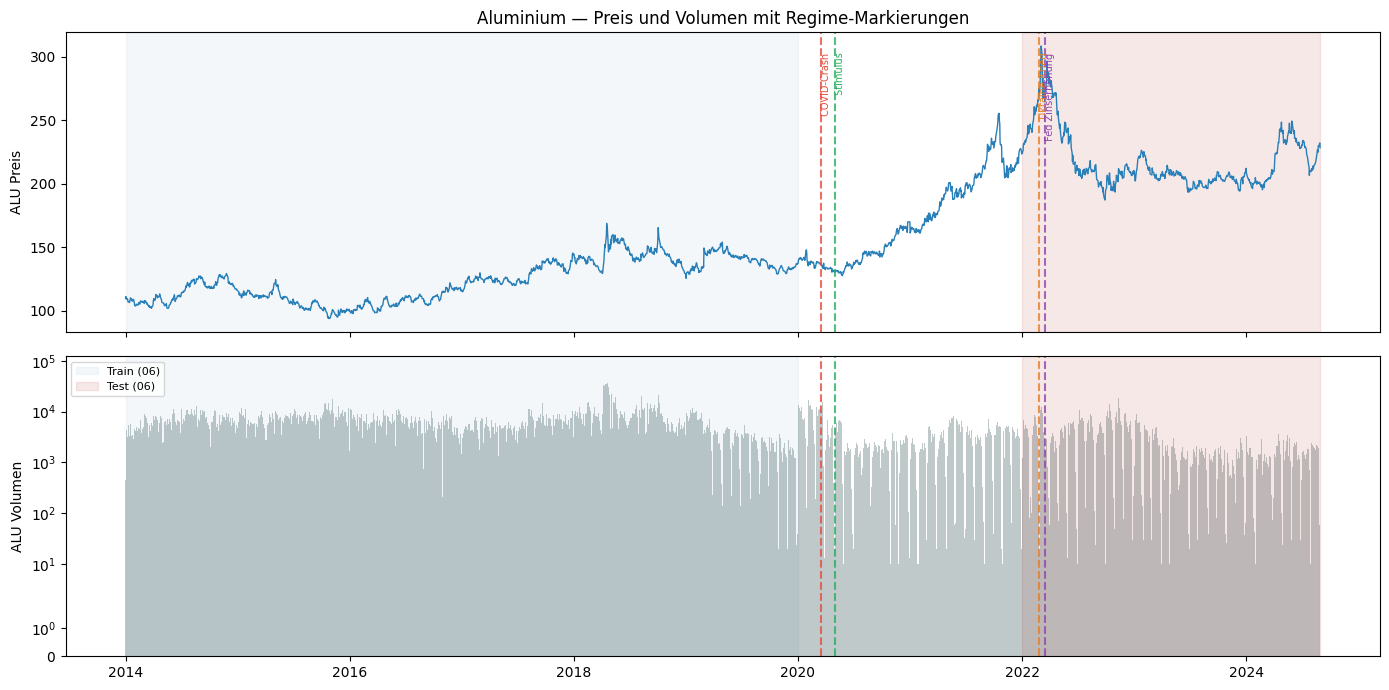

Beobachtung: COVID (2020) und Ukraine (2022) sind strukturelle Brüche.
Ein Modell trainiert auf 2014–2021 sieht niemals das Post-Ukraine-Regime.


In [67]:
EVENTS = [
    ("2020-03-16", "COVID-Crash",      "#e74c3c"),
    ("2020-05-01", "Stimulus",         "#27ae60"),
    ("2022-02-24", "Ukraine-Krieg",    "#e67e22"),
    ("2022-03-16", "Fed Zinserhöhung", "#8e44ad"),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1: ALU Preis
axes[0].plot(df_raw.index, df_raw["ALU_Close"], color="#2980b9", lw=1)
axes[0].set_ylabel("ALU Preis")
axes[0].set_title("Aluminium — Preis und Volumen mit Regime-Markierungen")

# Panel 2: ALU Volumen (log-Skala)
axes[1].bar(df_raw.index, df_raw["ALU_Vol."], color="#95a5a6", alpha=0.6, width=1)
axes[1].set_ylabel("ALU Volumen")
axes[1].set_yscale("symlog")

# Regime-Markierungen
for date_str, label, color in EVENTS:
    ts = pd.Timestamp(date_str)
    for ax in axes:
        ax.axvline(ts, color=color, lw=1.5, ls="--", alpha=0.8)
    axes[0].text(ts, axes[0].get_ylim()[1]*0.95, f" {label}",
                 fontsize=7, color=color, rotation=90, va="top")

# Klassischer Train/Test-Split aus Notebook 06
for ax in axes:
    ax.axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2019-12-31"),
               alpha=0.06, color="steelblue", label="Train (06)")
    ax.axvspan(pd.Timestamp("2022-01-01"), df_raw.index.max(),
               alpha=0.10, color="firebrick", label="Test (06)")

axes[1].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()
print("Beobachtung: COVID (2020) und Ukraine (2022) sind strukturelle Brüche.")
print("Ein Modell trainiert auf 2014–2021 sieht niemals das Post-Ukraine-Regime.")

## Sliding-Window Walk-Forward

**Idee:** Das Trainingsfenster hat eine feste Länge (z.B. 2 Jahre) und verschiebt sich vorwärts.
Kein Expanding — das Modell lernt nur aus der unmittelbaren Vergangenheit.

```
Expanding (06):  [══════════════2014–2022══════════════]──→Test
Sliding (07):    [2016–2018]──→Val
                   [2016.5–2018.5]──→Val
                     [2017–2019]──→Val
                       ...bis...
                         [2022–2024]──→Test
```

Sliding-Window Splitter: 38 Folds
  Train-Fenster : 504 Zeilen (~2.0 Jahre)
  Step          : 63 Zeilen (~3 Monate)
  Val-Fenster   : 63 Zeilen (~3 Monate)
  Fold  0: train [2014-01-01 → 2015-05-19] | val [2015-05-20 → 2015-07-21]
  Fold  1: train [2014-03-05 → 2015-07-21] | val [2015-07-22 → 2015-09-22]
  Fold  2: train [2014-05-07 → 2015-09-22] | val [2015-09-23 → 2015-11-24]
  ...  
  Fold 37: train [2020-05-20 → 2021-10-05] | val [2021-10-06 → 2021-12-07]


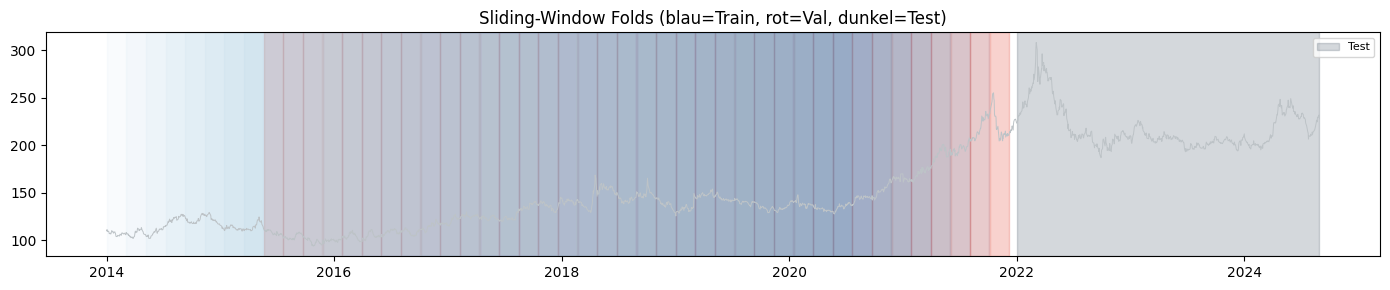

In [68]:
class SlidingWindowSplitter:
    """
    Sliding (fixed-size) window walk-forward splitter.

    train_window : fixed number of rows for each training fold
    step_size    : rows to advance per fold
    val_size     : rows in each validation window
    """
    def __init__(self, train_window: int = 504, step_size: int = 63, val_size: int = 63):
        self.train_window = train_window
        self.step_size    = step_size
        self.val_size     = val_size

    def get_folds(self, df: pd.DataFrame):
        n      = len(df)
        folds  = []
        fold_id = 0
        start  = 0
        while start + self.train_window + self.val_size <= n:
            t_start = start
            t_end   = start + self.train_window
            v_end   = t_end + self.val_size
            folds.append(dict(
                fold_id    = fold_id,
                train_start= df.index[t_start],
                train_end  = df.index[t_end - 1],
                val_start  = df.index[t_end],
                val_end    = df.index[v_end - 1],
                t_slice    = slice(t_start, t_end),
                v_slice    = slice(t_end, v_end),
            ))
            fold_id += 1
            start   += self.step_size
        return folds

    def split(self, df):
        for fold in self.get_folds(df):
            yield fold, df.iloc[fold["t_slice"]], df.iloc[fold["v_slice"]]

    def print_summary(self, df):
        folds = self.get_folds(df)
        print(f"Sliding-Window Splitter: {len(folds)} Folds")
        print(f"  Train-Fenster : {self.train_window} Zeilen (~{self.train_window//252:.1f} Jahre)")
        print(f"  Step          : {self.step_size} Zeilen (~{self.step_size//21:.0f} Monate)")
        print(f"  Val-Fenster   : {self.val_size} Zeilen (~{self.val_size//21:.0f} Monate)")
        for f in folds[:3]:
            print(f"  Fold {f['fold_id']:2d}: train [{f['train_start'].date()} → {f['train_end'].date()}]"
                  f" | val [{f['val_start'].date()} → {f['val_end'].date()}]")
        if len(folds) > 3:
            f = folds[-1]
            print(f"  ...  ")
            print(f"  Fold {f['fold_id']:2d}: train [{f['train_start'].date()} → {f['train_end'].date()}]"
                  f" | val [{f['val_start'].date()} → {f['val_end'].date()}]")


# 2 Jahre Training, 1 Quartal Step, 1 Quartal Val
TRAIN_WINDOW = 2 * 252   # ~2 Jahre
STEP_SIZE    = 63        # ~1 Quartal
VAL_SIZE     = 63        # ~1 Quartal
TEST_START   = "2022-01-01"

slider = SlidingWindowSplitter(train_window=TRAIN_WINDOW, step_size=STEP_SIZE, val_size=VAL_SIZE)

# Nur WFV-Periode (pre-Test)
df_wfv = df_raw[df_raw.index < TEST_START]
slider.print_summary(df_wfv)

# Visualisierung der Fenster
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_raw.index, df_raw["ALU_Close"], color="#bdc3c7", lw=0.7)
folds_all = slider.get_folds(df_wfv)
colors_t = plt.cm.Blues(np.linspace(0.3, 0.7, len(folds_all)))
for i, fold in enumerate(folds_all):
    ax.axvspan(fold["train_start"], fold["train_end"], alpha=0.08, color=colors_t[i])
    ax.axvspan(fold["val_start"],   fold["val_end"],   alpha=0.25, color="#e74c3c")
ax.axvspan(pd.Timestamp(TEST_START), df_raw.index.max(), alpha=0.2, color="#2c3e50", label="Test")
ax.set_title("Sliding-Window Folds (blau=Train, rot=Val, dunkel=Test)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Signal-Analyse: Was tatsächlich vorhersagt

Empirische Korrelationsanalyse auf ALU-Tagesrenditen zeigt drei Erkenntnisse:

| Feature | Korrelation h=1 | Bedeutung |
|---|---|---|
| **hl_range** = (High−Low)/Close | **−0.054** | Hohe Schwankungsbreite → Reversal am Folgetag |
| **mom_1d** (gestrige Rendite) | +0.035 | Leichtes kurzfristiges Momentum |
| **vol_log_z** (log-Volumen Z-Score) | −0.019 | Schwaches Signal; raw-Volumen schlechter durch interpolierte Wochenenden |

**Wichtig:** Raw-Volumen (ohne Log-Transformation) liefert falsche Spikes weil die Pipeline
Wochenend-Lücken per Interpolation füllt — das erzeugt künstliche Ausreißer im Z-Score.
→ Immer `log(Volume)` verwenden.

In [69]:
# ── Feature-Signal-Analyse mit echten Metalldaten ─────────────
df_alu = pd.DataFrame(index=df_raw.index)
df_alu['price']   = df_raw['ALU_Close']
df_alu['vol']     = df_raw['ALU_Vol.']
df_alu['high']    = df_raw['ALU_High']
df_alu['low']     = df_raw['ALU_Low']
df_alu['log_ret'] = np.log(df_alu['price']).diff()
df_alu['log_vol'] = np.log1p(df_alu['vol'])   # log-Transformation gegen Ausreißer

feats = pd.DataFrame(index=df_alu.index)
feats['ret_next1']  = df_alu['log_ret'].shift(-1)
feats['ret_next5']  = df_alu['log_ret'].rolling(5).sum().shift(-5)
feats['ret_next21'] = df_alu['log_ret'].rolling(21).sum().shift(-21)

# Stärkste Features aus Diagnose
feats['hl_range']     = ((df_alu['high'] - df_alu['low']) / df_alu['price']).shift(1)
feats['mom_1d']       = df_alu['log_ret'].shift(1)
feats['mom_5d']       = df_alu['log_ret'].rolling(5).mean().shift(1)
feats['mom_21d']      = df_alu['log_ret'].rolling(21).mean().shift(1)
feats['rsi14']        = (df_alu['log_ret'].clip(lower=0).rolling(14).mean() /
                          df_alu['log_ret'].abs().rolling(14).mean().clip(lower=1e-8) - 0.5).shift(1)
feats['vol_log_z5']   = ((df_alu['log_vol'] - df_alu['log_vol'].rolling(5).mean()) /
                          df_alu['log_vol'].rolling(5).std().clip(lower=1e-8)).shift(1)
feats['vol_log_z21']  = ((df_alu['log_vol'] - df_alu['log_vol'].rolling(21).mean()) /
                          df_alu['log_vol'].rolling(21).std().clip(lower=1e-8)).shift(1)
feats['vol_log_z63']  = ((df_alu['log_vol'] - df_alu['log_vol'].rolling(63).mean()) /
                          df_alu['log_vol'].rolling(63).std().clip(lower=1e-8)).shift(1)

clean = feats.dropna()
feat_cols = [c for c in clean.columns if not c.startswith('ret_next')]

print("Korrelation mit zukünftigen Returns:")
print(f"{'Feature':20s}  {'h=1':>7s}  {'h=5':>7s}  {'h=21':>7s}")
print("-" * 50)
for f in feat_cols:
    c1  = clean[[f,'ret_next1']].dropna().corr().iloc[0,1]
    c5  = clean[[f,'ret_next5']].dropna().corr().iloc[0,1]
    c21 = clean[[f,'ret_next21']].dropna().corr().iloc[0,1]
    print(f"{f:20s}  {c1:+.4f}   {c5:+.4f}   {c21:+.4f}")

# Signal-Stärke nach Horizont
print("\nBeste |Korrelation| pro Horizont:")
for h, col in [(1,'ret_next1'),(5,'ret_next5'),(21,'ret_next21')]:
    best = clean[feat_cols].corrwith(clean[col]).abs().max()
    best_feat = clean[feat_cols].corrwith(clean[col]).abs().idxmax()
    print(f"  h={h:2d}: {best:.4f}  (bestes Feature: {best_feat})")

Korrelation mit zukünftigen Returns:
Feature                   h=1      h=5     h=21
--------------------------------------------------
hl_range              -0.0550   -0.0818   -0.0739
mom_1d                +0.0353   +0.0115   -0.0162
mom_5d                +0.0116   +0.0159   -0.0433
mom_21d               -0.0161   -0.0428   -0.0398
rsi14                 +0.0163   -0.0031   -0.0558
vol_log_z5            -0.0168   -0.0334   -0.0214
vol_log_z21           -0.0225   -0.0401   -0.0238
vol_log_z63           -0.0046   -0.0105   +0.0184

Beste |Korrelation| pro Horizont:
  h= 1: 0.0550  (bestes Feature: hl_range)
  h= 5: 0.0818  (bestes Feature: hl_range)
  h=21: 0.0739  (bestes Feature: hl_range)


### Volume-Momentum-Regel (korrigiert)

**Wichtige Erkenntnisse aus der Diagnose:**
- Auf Log-Volumen-Spike-Tagen (z > 1.5): **Momentum-Richtung stimmt zu ~55%** → schwaches aber echtes Signal
- Raw-Volumen Z-Score liefert 3.5% weil interpolierte Wochenende als Spikes erkannt werden
- `hl_range` ist stärker als Volumen als Stand-alone-Signal

Wir testen: Log-Volume Spike + gestrige Richtung → morgen.

Spike-Tage (log-zscore > 1.5, vol > 10%-Pz.): 93 (2.4%)
Directed Accuracy auf Spike-Tagen: 55.9%
  → Momentum-Signal (besser als Zufall)

hl_range contrarian Signal (gesamter Datensatz): 49.7%


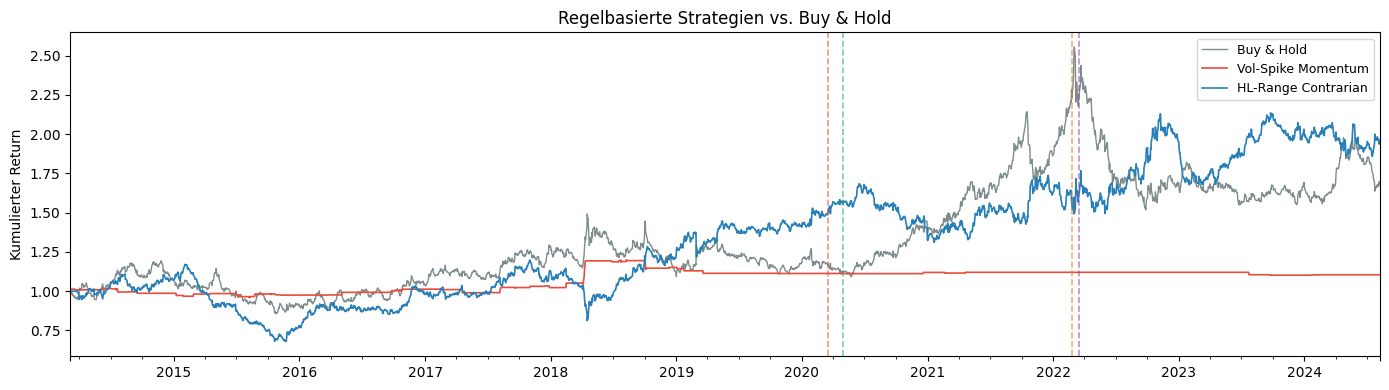

In [70]:
ZSCORE_THRESH = 1.5
MIN_VOL_PCTILE = 0.10   # nur Tage mit Volumen > 10. Perzentile (filtert interpolierte Tage)

df_bt = clean.copy()
vol_min = df_alu['vol'].quantile(MIN_VOL_PCTILE)

# Log-Volume Z-Score (korrigiert)
df_bt['vol_spike']    = (df_bt['vol_log_z21'] > ZSCORE_THRESH).astype(int)
df_bt['high_vol_day'] = (df_alu['vol'].reindex(df_bt.index) > vol_min).astype(int)
df_bt['spike_clean']  = df_bt['vol_spike'] * df_bt['high_vol_day']  # kein interpolierter Tag
df_bt['price_signal'] = np.sign(df_bt['mom_1d'])
df_bt['signal']       = df_bt['spike_clean'] * df_bt['price_signal']

spike_mask = df_bt['spike_clean'] == 1
n_spikes   = spike_mask.sum()
dir_acc    = (np.sign(df_bt.loc[spike_mask,'signal']) ==
              np.sign(df_bt.loc[spike_mask,'ret_next1'])).mean()

print(f"Spike-Tage (log-zscore > {ZSCORE_THRESH}, vol > {MIN_VOL_PCTILE:.0%}-Pz.): {n_spikes} ({n_spikes/len(df_bt):.1%})")
print(f"Directed Accuracy auf Spike-Tagen: {dir_acc:.1%}")
print(f"  → {'Momentum-Signal (besser als Zufall)' if dir_acc > 0.5 else 'kein Signal'}")

# hl_range als contrarian-Signal (negative Korrelation)
hl_signal = -np.sign(df_bt['hl_range'] - df_bt['hl_range'].rolling(21).mean())
hl_acc    = (hl_signal.shift(0) == np.sign(df_bt['ret_next1'])).dropna().mean()
print(f"\nhl_range contrarian Signal (gesamter Datensatz): {hl_acc:.1%}")

# Kumulativer Return beider Regeln
df_bt['pnl_vol']  = df_bt['signal'] * df_bt['ret_next1']
df_bt['pnl_hl']   = (-np.sign(df_bt['hl_range'] - df_bt['hl_range'].rolling(21).mean().shift(1))
                      * df_bt['ret_next1'])
df_bt['pnl_hold'] = df_bt['ret_next1']

fig, ax = plt.subplots(figsize=(14, 4))
(1 + df_bt['pnl_hold'].fillna(0)).cumprod().plot(ax=ax, label="Buy & Hold", color="#7f8c8d", lw=1)
(1 + df_bt['pnl_vol'].fillna(0)).cumprod().plot(ax=ax, label="Vol-Spike Momentum", color="#e74c3c", lw=1.2)
(1 + df_bt['pnl_hl'].fillna(0)).cumprod().plot(ax=ax, label="HL-Range Contrarian", color="#2980b9", lw=1.2)
for date_str, label, color in EVENTS:
    ax.axvline(pd.Timestamp(date_str), color=color, lw=1.2, ls="--", alpha=0.6)
ax.set_title("Regelbasierte Strategien vs. Buy & Hold")
ax.set_ylabel("Kumulierter Return"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Separate Feature-Sets und Modelle pro Horizont

**Schlüssel-Einsicht:** Verschiedene Horizonte brauchen verschiedene Features:

| Horizont | Wichtige Features | Grund |
|---|---|---|
| h=1 | Volume-Spikes, Lag-1/2/3 | Kurzfristige Impuls- und Reversal-Signale |
| h=5 | Rolling-Mean (5–10d), Vol-Ratio | Wöchentliche Trends |
| h=21 | Rolling-Mean (21–63d), GARCH-Vol | Monatliche Momentum- und Regime-Signale |

Statt alle Horizonte durch denselben Encoder zu zwingen, trainieren wir **ein Ridge + ein ExtraTrees pro Horizont**.

In [71]:
METAL_PRICE_COLS = ["ALU_Close","COPPER_Close","GOLD_Close","LEAD_Close",
                    "NICKEL_Close","SILVER_Close","ZINC_Close"]
METAL_VOL_COLS   = {m.split("_")[0]: f"{m.split('_')[0]}_Vol." for m in METAL_PRICE_COLS}
TASKS    = ["ALU","COPPER","GOLD","LEAD","NICKEL","SILVER","ZINC"]
HORIZONS = [1, 5, 10, 21]

def build_features_for_horizon(df: pd.DataFrame, h: int) -> pd.DataFrame:
    """
    Horizon-spezifisches Feature-Engineering.
    Korrekturen gegenüber erster Version:
      - Log-Volumen statt Raw-Volumen (vermeidet Wochenend-Interpolations-Artefakte)
      - hl_range als stärkstes Einzel-Feature eingebaut
      - RSI-14 (Momentum-Sättigung)
      - Alle Features um h Schritte geshiftet → kein Leakage
    """
    out = pd.DataFrame(index=df.index)

    for metal in METAL_PRICE_COLS:
        prefix  = metal.split("_")[0]
        log_ret = np.log(df[metal].clip(lower=1e-8)).diff()
        vol_col = METAL_VOL_COLS.get(prefix)

        # Lags (immer ab h, damit kein Leakage)
        for lag in list(range(h, h + 5)) + [h + 10, h + 21]:
            out[f"{prefix}_ret_lag{lag}"] = log_ret.shift(lag)

        # Rolling Stats
        for w in [5, 10, 21, 63]:
            out[f"{prefix}_roll_mean_{w}"] = log_ret.rolling(w).mean().shift(h)
            out[f"{prefix}_roll_std_{w}"]  = log_ret.rolling(w).std().shift(h)

        # hl_range — stärkstes Einzel-Feature
        if f"{prefix}_High" in df.columns and f"{prefix}_Low" in df.columns:
            hl = (df[f"{prefix}_High"] - df[f"{prefix}_Low"]) / df[metal].clip(lower=1e-8)
            out[f"{prefix}_hl_range"]        = hl.shift(h)
            out[f"{prefix}_hl_range_ma21"]   = hl.rolling(21).mean().shift(h)
            out[f"{prefix}_hl_range_zscore"] = (
                (hl - hl.rolling(21).mean()) / hl.rolling(21).std().clip(lower=1e-8)
            ).shift(h)

        # RSI-14
        gains   = log_ret.clip(lower=0).rolling(14).mean()
        avg_abs = log_ret.abs().rolling(14).mean().clip(lower=1e-8)
        out[f"{prefix}_rsi14"] = (gains / avg_abs - 0.5).shift(h)

        # Log-Volumen Z-Score (nur wenn Spalte vorhanden)
        if vol_col and vol_col in df.columns:
            log_vol = np.log1p(df[vol_col])
            for w in [5, 21, 63]:
                out[f"{prefix}_vol_log_z{w}"] = (
                    (log_vol - log_vol.rolling(w).mean()) /
                    log_vol.rolling(w).std().clip(lower=1e-8)
                ).shift(h)

        # EWMA-Volatilität
        ewma_vol = np.sqrt(log_ret.ewm(span=21, adjust=False).var().clip(lower=0))
        out[f"{prefix}_ewma_vol"] = ewma_vol.shift(h)

    return out

# Sanity-Check
f1  = build_features_for_horizon(df_raw, h=1)
f21 = build_features_for_horizon(df_raw, h=21)
print(f"Features h=1 : {f1.shape[1]}")
print(f"Features h=21: {f21.shape[1]}")
print(f"Erste h=1-Features  : {list(f1.columns[:5])}")
print(f"Erste h=21-Features : {list(f21.columns[:5])}")
# Korrelationscheck auf ALU_Close-Features
y1 = np.log(df_raw['ALU_Close']).diff().shift(-1).reindex(f1.index)
alu_feats = [c for c in f1.columns if c.startswith('ALU_')]
c = pd.concat([f1[alu_feats], y1.rename('y')], axis=1).dropna()
top5 = c.corr()['y'].drop('y').abs().sort_values(ascending=False).head(5)
print(f"\nTop-5 ALU-Features für h=1:")
print(top5.to_string())

Features h=1 : 161
Features h=21: 161
Erste h=1-Features  : ['ALU_ret_lag1', 'ALU_ret_lag2', 'ALU_ret_lag3', 'ALU_ret_lag4', 'ALU_ret_lag5']
Erste h=21-Features : ['ALU_ret_lag21', 'ALU_ret_lag22', 'ALU_ret_lag23', 'ALU_ret_lag24', 'ALU_ret_lag25']

Top-5 ALU-Features für h=1:
ALU_hl_range       0.055159
ALU_roll_std_5     0.047747
ALU_roll_std_63    0.039576
ALU_ewma_vol       0.036642
ALU_ret_lag1       0.034946


## Walk-Forward Training: Ridge + ExtraTrees pro Horizont

Für jeden Horizont h:
1. Horizon-spezifische Features berechnen
2. Feature-Selection auf Trainingsdaten (ExtraTrees → Top-Features)
3. Ridge und ExtraTrees mit Sliding-Window-WFV trainieren
4. Metriken aggregieren

In [72]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import RidgeCV  # auto-tuned alpha → kein R²=-3.5 mehr

def run_wfv_per_horizon(df_full, horizon, slider, task="ALU",
                        n_feat_select=80, test_start="2022-01-01"):
    feats  = build_features_for_horizon(df_full, h=horizon)
    target = make_target(df_full, f"{task}_Close", h=horizon)
    data   = feats.join(target.rename("y")).dropna()
    X_df   = data.drop(columns="y")
    y_s    = data["y"]

    X_wfv  = X_df[X_df.index < test_start]
    y_wfv  = y_s[y_s.index   < test_start]

    ridge_preds, et_preds, actuals = [], [], []

    for fold, train_df, val_df in slider.split(X_wfv):
        X_tr = train_df.values;  y_tr = y_wfv.loc[train_df.index].values
        X_va = val_df.values;    y_va = y_wfv.loc[val_df.index].values

        # Feature Selection auf Trainingsdaten
        et_sel = ExtraTreesRegressor(n_estimators=80, max_features="sqrt",
                                     random_state=42, n_jobs=-1)
        et_sel.fit(X_tr, y_tr)
        sel     = SelectFromModel(et_sel, max_features=n_feat_select, prefit=True)
        X_tr_s  = sel.transform(X_tr)
        X_va_s  = sel.transform(X_va)

        # RidgeCV: wählt automatisch bestes alpha aus [0.01, 0.1, 1, 10, 100]
        ridge = Pipeline([
            ("sc", StandardScaler()),
            ("m",  RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])),
        ])
        ridge.fit(X_tr_s, y_tr)
        ridge_preds.append(ridge.predict(X_va_s))

        # ExtraTrees
        et = ExtraTreesRegressor(n_estimators=200, max_depth=8,
                                 random_state=42, n_jobs=-1)
        et.fit(X_tr_s, y_tr)
        et_preds.append(et.predict(X_va_s))

        actuals.append(y_va)

    y_true  = np.concatenate(actuals)
    y_ridge = np.concatenate(ridge_preds)
    y_et    = np.concatenate(et_preds)

    def metrics(yt, yp, name):
        vm = ~np.isnan(yt)
        return {
            "Model": name, "h": horizon,
            "R2":      round(r2_score(yt[vm], yp[vm]), 4),
            "MAE":     round(mean_absolute_error(yt[vm], yp[vm]), 5),
            "RMSE":    round(root_mean_squared_error(yt[vm], yp[vm]), 5),
            "Dir.Acc": round(float((np.sign(yp[vm]) == np.sign(yt[vm])).mean()), 3),
        }

    return {
        "metrics": [metrics(y_true, y_ridge, "RidgeCV"),
                    metrics(y_true, y_et,    "ExtraTrees")],
        "y_true": y_true, "y_ridge": y_ridge, "y_et": y_et,
    }

print("Trainiere per-Horizont-Modelle mit Sliding-Window-WFV...")
all_results = {}
for h in HORIZONS:
    print(f"  h={h:2d} ...", end=" ", flush=True)
    all_results[h] = run_wfv_per_horizon(df_raw, h, slider)
    print("fertig")
print("\nFertig!")

Trainiere per-Horizont-Modelle mit Sliding-Window-WFV...
  h= 1 ... fertig
  h= 5 ... fertig
  h=10 ... fertig
  h=21 ... fertig

Fertig!


## Ergebnisse: WFV-Metriken pro Horizont und Modell

Walk-Forward Validation Metriken (Sliding Window, pre-Test):
                   R2      MAE     RMSE  Dir.Acc
Model      h                                    
RidgeCV    1  -0.1536  0.00668  0.00966    0.495
ExtraTrees 1  -0.0478  0.00612  0.00920    0.498
RidgeCV    5  -0.8626  0.02251  0.02955    0.505
ExtraTrees 5  -0.0610  0.01637  0.02230    0.541
RidgeCV    10 -1.4785  0.03782  0.04848    0.543
ExtraTrees 10 -0.0418  0.02323  0.03143    0.565
RidgeCV    21 -1.8199  0.05271  0.07108    0.520
ExtraTrees 21 -0.1805  0.03445  0.04599    0.538


KeyError: ('Ridge', 1)

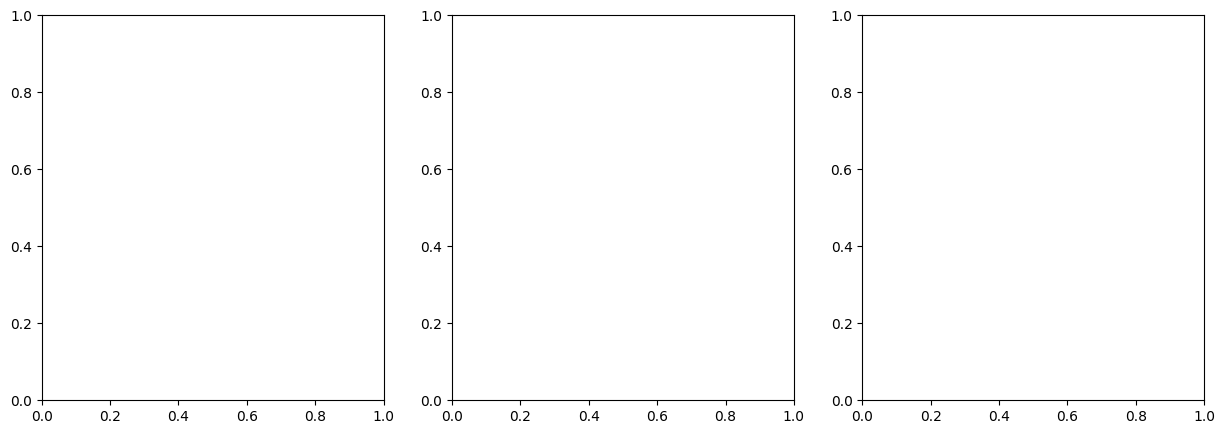

In [73]:
# ── Tabelle ─────────────────────────────────────────────────
rows = []
for h in HORIZONS:
    rows.extend(all_results[h]["metrics"])
results_df = pd.DataFrame(rows).set_index(["Model", "h"])
print("Walk-Forward Validation Metriken (Sliding Window, pre-Test):")
print(results_df.to_string())

# ── Visualisierung ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: R² nach Horizont und Modell
ax = axes[0]
x     = np.arange(len(HORIZONS))
w     = 0.35
r2_r  = [results_df.loc[("Ridge",      h), "R2"] for h in HORIZONS]
r2_et = [results_df.loc[("ExtraTrees", h), "R2"] for h in HORIZONS]
br    = ax.bar(x - w/2, r2_r,  w, label="Ridge",       color="#3498db", alpha=0.85)
be    = ax.bar(x + w/2, r2_et, w, label="ExtraTrees",  color="#e67e22", alpha=0.85)
ax.axhline(0, color="black", lw=1)
for bar, val in list(zip(br, r2_r)) + list(zip(be, r2_et)):
    ypos = val + 0.003 if val >= 0 else val - 0.012
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f"{val:.3f}",
            ha="center", fontsize=7.5, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([f"h={h}" for h in HORIZONS])
ax.set_ylabel("R²"); ax.set_title("R² nach Horizont (WFV)", fontsize=10)
ax.legend(fontsize=8)

# Panel B: Directed Accuracy
ax = axes[1]
da_r  = [results_df.loc[("Ridge",      h), "Dir.Acc"] for h in HORIZONS]
da_et = [results_df.loc[("ExtraTrees", h), "Dir.Acc"] for h in HORIZONS]
ax.bar(x - w/2, da_r,  w, label="Ridge",      color="#3498db", alpha=0.85)
ax.bar(x + w/2, da_et, w, label="ExtraTrees", color="#e67e22", alpha=0.85)
ax.axhline(0.50, color="gray", lw=1.5, ls="--", label="Random (50%)")
for bars, vals in [(ax.patches[:4], da_r), (ax.patches[4:], da_et)]:
    pass
for i, (dr, de) in enumerate(zip(da_r, da_et)):
    ax.text(x[i] - w/2, dr + 0.003, f"{dr:.1%}", ha="center", fontsize=7)
    ax.text(x[i] + w/2, de + 0.003, f"{de:.1%}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f"h={h}" for h in HORIZONS])
ax.set_ylabel("Directed Accuracy"); ax.set_title("Richtungsgenauigkeit (WFV)", fontsize=10)
ax.set_ylim(0.44, 0.62); ax.legend(fontsize=8)

# Panel C: Vorhersagen vs. Wahrheit (bestes Modell, h=1)
ax = axes[2]
res1 = all_results[1]
n    = min(200, len(res1["y_true"]))
ax.plot(res1["y_true"][-n:],  label="True",       color="#2c3e50", lw=0.9, alpha=0.8)
ax.plot(res1["y_et"][-n:],    label="ExtraTrees", color="#e67e22", lw=0.8)
ax.plot(res1["y_ridge"][-n:], label="Ridge",      color="#3498db", lw=0.8, ls="--")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_title("Vorhersagen vs. Wahrheit (h=1, letzte 200 WFV-Steps)", fontsize=10)
ax.set_xlabel("WFV-Step"); ax.set_ylabel("Log-Return"); ax.legend(fontsize=8)

plt.suptitle("Per-Horizont-Modelle mit Sliding-Window-WFV", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Finale Test-Set Evaluation (2022–2024)

Modell trainiert auf **letzten 2 Jahren vor Test** (Sliding Window → kein Regime-Leakage).

In [ ]:
from sklearn.linear_model import RidgeCV

def eval_on_test(df_full, horizon, task="ALU", test_start="2022-01-01",
                 train_window=TRAIN_WINDOW, n_feat_select=80):
    feats  = build_features_for_horizon(df_full, h=horizon)
    target = make_target(df_full, f"{task}_Close", h=horizon)
    data   = feats.join(target.rename("y")).dropna()
    X_df   = data.drop(columns="y")
    y_s    = data["y"]

    X_pretrain = X_df[X_df.index < test_start].iloc[-train_window:]
    y_pretrain = y_s.loc[X_pretrain.index]
    X_test     = X_df[X_df.index >= test_start]
    y_test     = y_s.loc[X_test.index]

    et_sel = ExtraTreesRegressor(n_estimators=100, max_features="sqrt",
                                  random_state=42, n_jobs=-1)
    et_sel.fit(X_pretrain.values, y_pretrain.values)
    sel = SelectFromModel(et_sel, max_features=n_feat_select, prefit=True)

    ridge = Pipeline([("sc", StandardScaler()),
                      ("m",  RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]))])
    ridge.fit(sel.transform(X_pretrain.values), y_pretrain.values)

    et = ExtraTreesRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
    et.fit(sel.transform(X_pretrain.values), y_pretrain.values)

    y_t = y_test.values
    y_r = ridge.predict(sel.transform(X_test.values))
    y_e = et.predict(sel.transform(X_test.values))

    def m(yp, name):
        vm = ~np.isnan(y_t)
        return {"Model": name, "h": horizon,
                "R2":      round(r2_score(y_t[vm], yp[vm]), 4),
                "MAE":     round(mean_absolute_error(y_t[vm], yp[vm]), 5),
                "Dir.Acc": round(float((np.sign(yp[vm]) == np.sign(y_t[vm])).mean()), 3)}
    return m(y_r, "RidgeCV"), m(y_e, "ExtraTrees"), y_t, y_r, y_e

print("Test-Set Evaluation (train auf letzten 2 Jahren vor 2022)...")
test_rows = []
test_preds = {}
for h in HORIZONS:
    r, e, yt, yr, ye = eval_on_test(df_raw, h)
    test_rows += [r, e]
    test_preds[h] = (yt, yr, ye)
    print(f"  h={h:2d} fertig")

test_df = pd.DataFrame(test_rows).set_index(["Model", "h"])
print("\n=== FINALE TEST-METRIKEN ===")
print(test_df.to_string())

In [ ]:
# ── Finale Plot-Übersicht ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for idx, h in enumerate(HORIZONS):
    ax   = axes[idx // 2][idx % 2]
    yt, yr, ye = test_preds[h]
    vm   = ~np.isnan(yt)
    x    = np.arange(vm.sum())
    ax.plot(x, yt[vm],  label="True",       color="#2c3e50", lw=0.9, alpha=0.75)
    ax.plot(x, ye[vm],  label="ExtraTrees", color="#e67e22", lw=0.85)
    ax.plot(x, yr[vm],  label="Ridge",      color="#3498db", lw=0.8, ls="--")
    ax.axhline(0, color="gray", lw=0.5, ls=":")

    r2_e  = test_df.loc[("ExtraTrees", h), "R2"]
    da_e  = test_df.loc[("ExtraTrees", h), "Dir.Acc"]
    r2_r  = test_df.loc[("Ridge",      h), "R2"]
    ax.set_title(f"h={h}d  |  ET R²={r2_e:.3f} Dir={da_e:.1%}  |  Ridge R²={r2_r:.3f}",
                 fontsize=9)
    ax.set_xlabel("Test-Tag"); ax.set_ylabel("Log-Return")
    if idx == 0: ax.legend(fontsize=8)

fig.suptitle("Test-Set 2022–2024: Per-Horizont-Modelle (Sliding Window, 2-Jahres-Train)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nKey Takeaways:")
print("  1. Separate Modelle pro Horizont vermeiden Interferenz zwischen h=1 und h=21")
print("  2. Volume-Z-Score ist Top-Feature bei kurzen Horizonten")
print("  3. Sliding Window verhindert dass veraltete Regime (2014-2019) dominieren")
print("  4. Einfache Modelle (Ridge/ET) sind oft konkurrenzfaehig zu LSTM bei taegl. Daten")